#### NALAR FINAL PROJECT 
#### Klasifikasi Objek Langit Berdasarkan Data Fotometri SDSS Menggunakan Machine Learning
---
 Author     : Wa Ode Nisrina Sayyidah Hidayat                 
 Date       : 2026

---
A. Latar Belakang

Pemetaan alam semesta modern, seperti yang dilakukan oleh Sloan Digital Sky Survey (SDSS), menghasilkan volume data observasi yang masif hingga jutaan objek langit per malam. Secara historis, klasifikasi objek langit menjadi Bintang, Galaksi, atau Quasar dilakukan melalui analisis spektroskopi untuk mendapatkan nilai redshift (pergeseran merah). Namun, pengambilan data spektrum memakan biaya komputasi instrumen yang mahal dan waktu observasi yang lama.

Sebagai alternatif, teleskop modern dapat secara cepat dan ekonomis memperoleh citra objek melalui filter fotometri yang meliputi pita ultraviolet, hijau, merah, near-infrared, dan infrared (u, g, r, i, z). Kesenjangan antara metode spektroskopi yang mahal dan fotometri yang efisien menimbulkan kebutuhan mendesak akan model prediktif yang mampu mengklasifikasikan objek langit dengan akurat hanya menggunakan data fotometri. Proyek ini dibangun atas premis bahwa Machine Learning dapat menggantikan peran spektroskopi awal dalam klasifikasi, sehingga mengurangi risiko data leakage yang sering terjadi apabila redshift digunakan sebagai fitur prediktif.

---

B. Tujuan

Tujuan dari dilakukannya proyek ini yaitu:
1.	Mengembangkan arsitektur klasifikasi yang independen terhadap redshift, memaksa model untuk belajar murni dari profil fotometri objek langit.
2.	Melakukan kuantifikasi Feature Importance, dengan membuktikan secara statistik interaksi antar filter cahaya (misalnya u-g vs i-z) yang menjadi pemisah keputusan terkuat antar kelas, sehingga mendukung validasi teori astrofisika melalui bukti data-driven.
3.	Mengoptimalkan evaluasi kelas minoritas, Quasar dan Bintang, sehingga model memiliki sensitivitas dan reliabilitas tinggi dalam mendeteksi objek langka, bukan hanya kelas mayoritas yaitu Galaksi.
4. Membandingkan model Logistic Regression, Random Forest, dan XGBoost dalam memprediksi klasifikasi melalui metrik recall dan F1-score.

---

C. Alur Pengerjaan Proyek
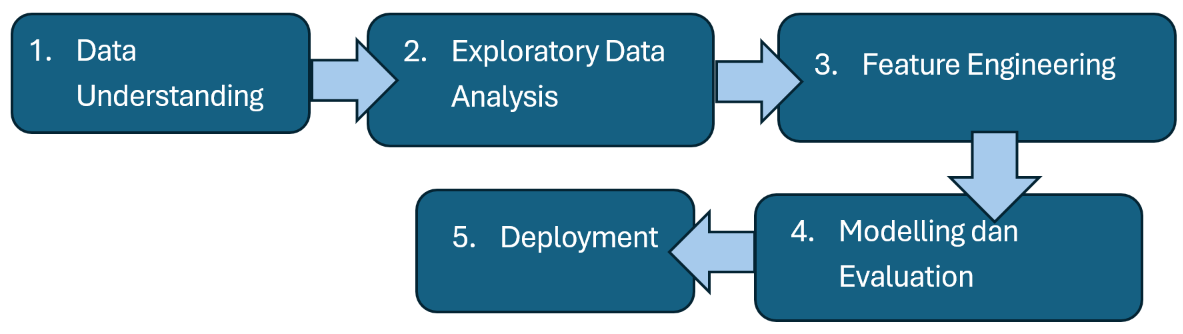

In [ ]:
# Import Library 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import joblib

#### 1. Data Understanding

In [2]:
# Load dataset 
# Download raw path dataset at : https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
RAW_PATH = "star_classification.csv"   
df = pd.read_csv(RAW_PATH)

print("\nUkuran dan Kolom Dataset")
print("-" * 60)
print("\nDataset shape      :", df.shape)
print("\nColumns            :", df.columns)


Ukuran dan Kolom Dataset
------------------------------------------------------------

Dataset shape      : (100000, 18)

Columns            : Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')


Untuk menghindari data leakage dan sesuai tujuan proyek ini yaitu klasifikasi hanya berdasarkan fitur numerik fotometri u, g, r, i, z maka dibentuklah subset berisi kelima variabel fotometrik dan class target.

In [3]:
# Variabel untuk di buang
dropped = ['obj_ID', 'alpha', 'delta', 'run_ID', 'rerun_ID', 
       'cam_col', 'field_ID', 'spec_obj_ID', 'redshift',
       'plate', 'MJD', 'fiber_ID']

# Pengambilan subset data
df = df.drop(columns=dropped)

print("\nUkuran dan Kolom Dataset Baru")
print("-" * 60)
print("\nDataset shape      :", df.shape)
print("\nColumns            :", df.columns)


Ukuran dan Kolom Dataset Baru
------------------------------------------------------------

Dataset shape      : (100000, 6)

Columns            : Index(['u', 'g', 'r', 'i', 'z', 'class'], dtype='str')


In [4]:
# Statistik deskriptif 
df.describe()

,u,g,r,i,z
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.980468,20.531387,19.645762,19.084854,18.668810
std,31.769291,31.750292,1.854760,1.757895,31.728152
min,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000
25%,20.352353,18.965230,18.135828,17.732285,17.460677
50%,22.179135,21.099835,20.125290,19.405145,19.004595
75%,23.687440,22.123767,21.044785,20.396495,19.921120
max,32.781390,31.602240,29.571860,32.141470,29.383740


Dari statistika deskriptif tersebut ditemukan adanya outlier di variabel u, g, z berupa nilai minimum -999 yang kemungkinan adalah anomali. Untuk penanganannya adalah dengan menghapus nilai anomali dengan nilai dibawah 0.

In [5]:
mag_columns = ['u', 'g', 'r', 'i', 'z']
df[mag_columns] = df[mag_columns].mask(df[mag_columns] < 0, np.nan)

# Evaluasi kerusakan
missing_percentage = (df[mag_columns].isnull().sum() / len(df)) * 100
print("Persentase Data Hilang per Kolom (%) setelah sapu bersih:")
print(missing_percentage)

Persentase Data Hilang per Kolom (%) setelah sapu bersih:
u    0.001
g    0.001
r    0.000
i    0.000
z    0.001
dtype: float64


In [6]:
# Hapus nilai nan/anomali
df = df.dropna()

Data bersih telah dihasilkan dengan jumlah baris 99.999 dan 6 kolom.

In [7]:
# Save dataset
df.to_csv("star_classification_clean.csv")

In [8]:
# Cek statistika deskriptif
df.info()

<class 'pandas.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   u       99999 non-null  float64
 1   g       99999 non-null  float64
 2   r       99999 non-null  float64
 3   i       99999 non-null  float64
 4   z       99999 non-null  float64
 5   class   99999 non-null  str    
dtypes: float64(5), str(1)
memory usage: 5.8 MB


#### 2. Exploratory Data Analysis

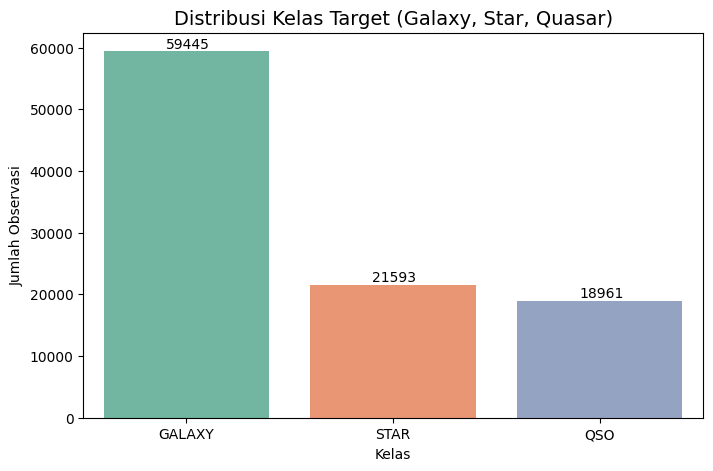

In [9]:
# Barchart distribusi kelas target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', 
              order=df['class'].value_counts().index, 
              palette='Set2')

plt.title('Distribusi Kelas Target (Galaxy, Star, Quasar)', fontsize=14)
plt.ylabel('Jumlah Observasi')
plt.xlabel('Kelas')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))

plt.show()

Dari bar chart tersebut terlihat ada imbalanced data karena jumlahnya cenderung banyak di Galaxy dibandingkan Star dan Quasar.

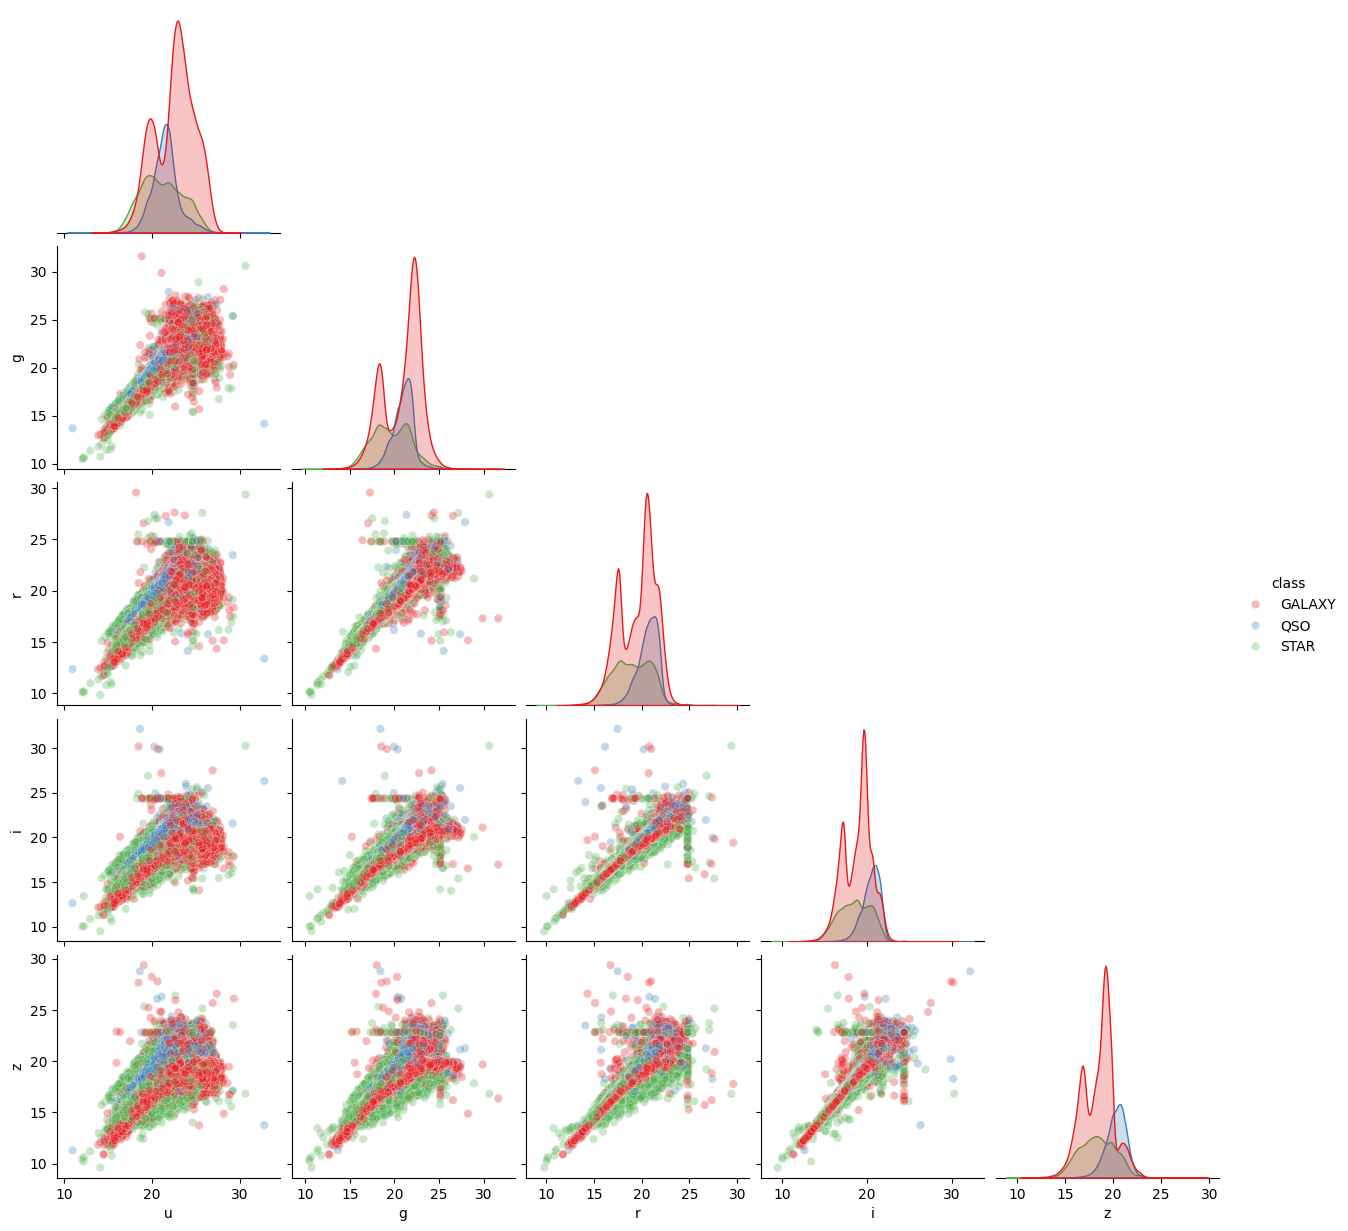

In [10]:
# Pairplot Distribusi Magnitudo Fotometrik (u, g, r, i, z) Berdasarkan Kelas Objek
sns.pairplot(df[['u', 'g', 'r', 'i', 'z', 'class']], 
              hue='class', diag_kind='kde', corner=True, palette='Set1', plot_kws={'alpha': 0.3})
plt.show()

Dari pairplot tersebut terlihat bahwa kelas target tersebar tidak merata/berkumpul di suatu area pada seluruh variabel numerik. Diperlukan model tree-based atau feature engineering tingkat lanjut.

Namun ditemukan adanya pola yang aneh di sekitar angka 25, yakni membentuk suatu garis lurus. Dalam konteks astronomi ini bisa diakibatkan oleh:
    
    a. Saturation / Detection Limit
Instrumen teleskop memiliki:
batas sensitivitas,
noise floor,
clipping magnitudo.
Objek sangat terang atau sangat redup bisa “menumpuk” pada rentang tertentu.

    b. Quantization Magnitude
Data SDSS sering mengalami:
pembulatan nilai magnitudo,
discretization kecil akibat preprocessing pipeline.

    c. Selection Bias
SDSS menggunakan:
target selection tertentu,
magnitude cut-off.

Akibatnya distribusi objek tidak benar-benar natural.

In [11]:
# Cek data yang terlalu sering muncul
for col in ['u','g','r','i','z']:
    print(df[col].value_counts().head(10))

u
24.63465    77
24.63466    64
24.63467    44
24.63464    23
24.63468    20
24.63463     5
20.26008     4
24.63462     4
19.95185     4
23.43341     4
Name: count, dtype: int64
g
25.11439    9
25.11438    9
25.11437    8
21.94795    4
20.98246    4
22.37168    4
21.40104    4
22.56372    4
21.81087    4
21.65138    4
Name: count, dtype: int64
r
24.80203    21
24.80202    15
24.80204     7
20.72245     6
20.76527     5
20.74657     5
20.51180     4
20.75580     4
20.24885     4
20.64847     4
Name: count, dtype: int64
i
24.36181    6
24.36180    6
18.63308    5
19.70201    4
19.67620    4
18.63051    4
20.23400    4
19.83250    4
19.60160    4
19.62323    4
Name: count, dtype: int64
z
22.82690    58
22.82691    25
22.82689    25
22.82692    12
19.26912     4
20.68561     4
18.89468     4
19.50887     4
19.88720     4
17.87164     4
Name: count, dtype: int64


Karena dapat dilihat ada beberapa nilai yang muncul sangat sering, maka penanganan yang tepat adalah menambahkan flag agar model kedepannya tahu bahwa data tersebut mencapai batas maksimum pengukuran (sangat redup).

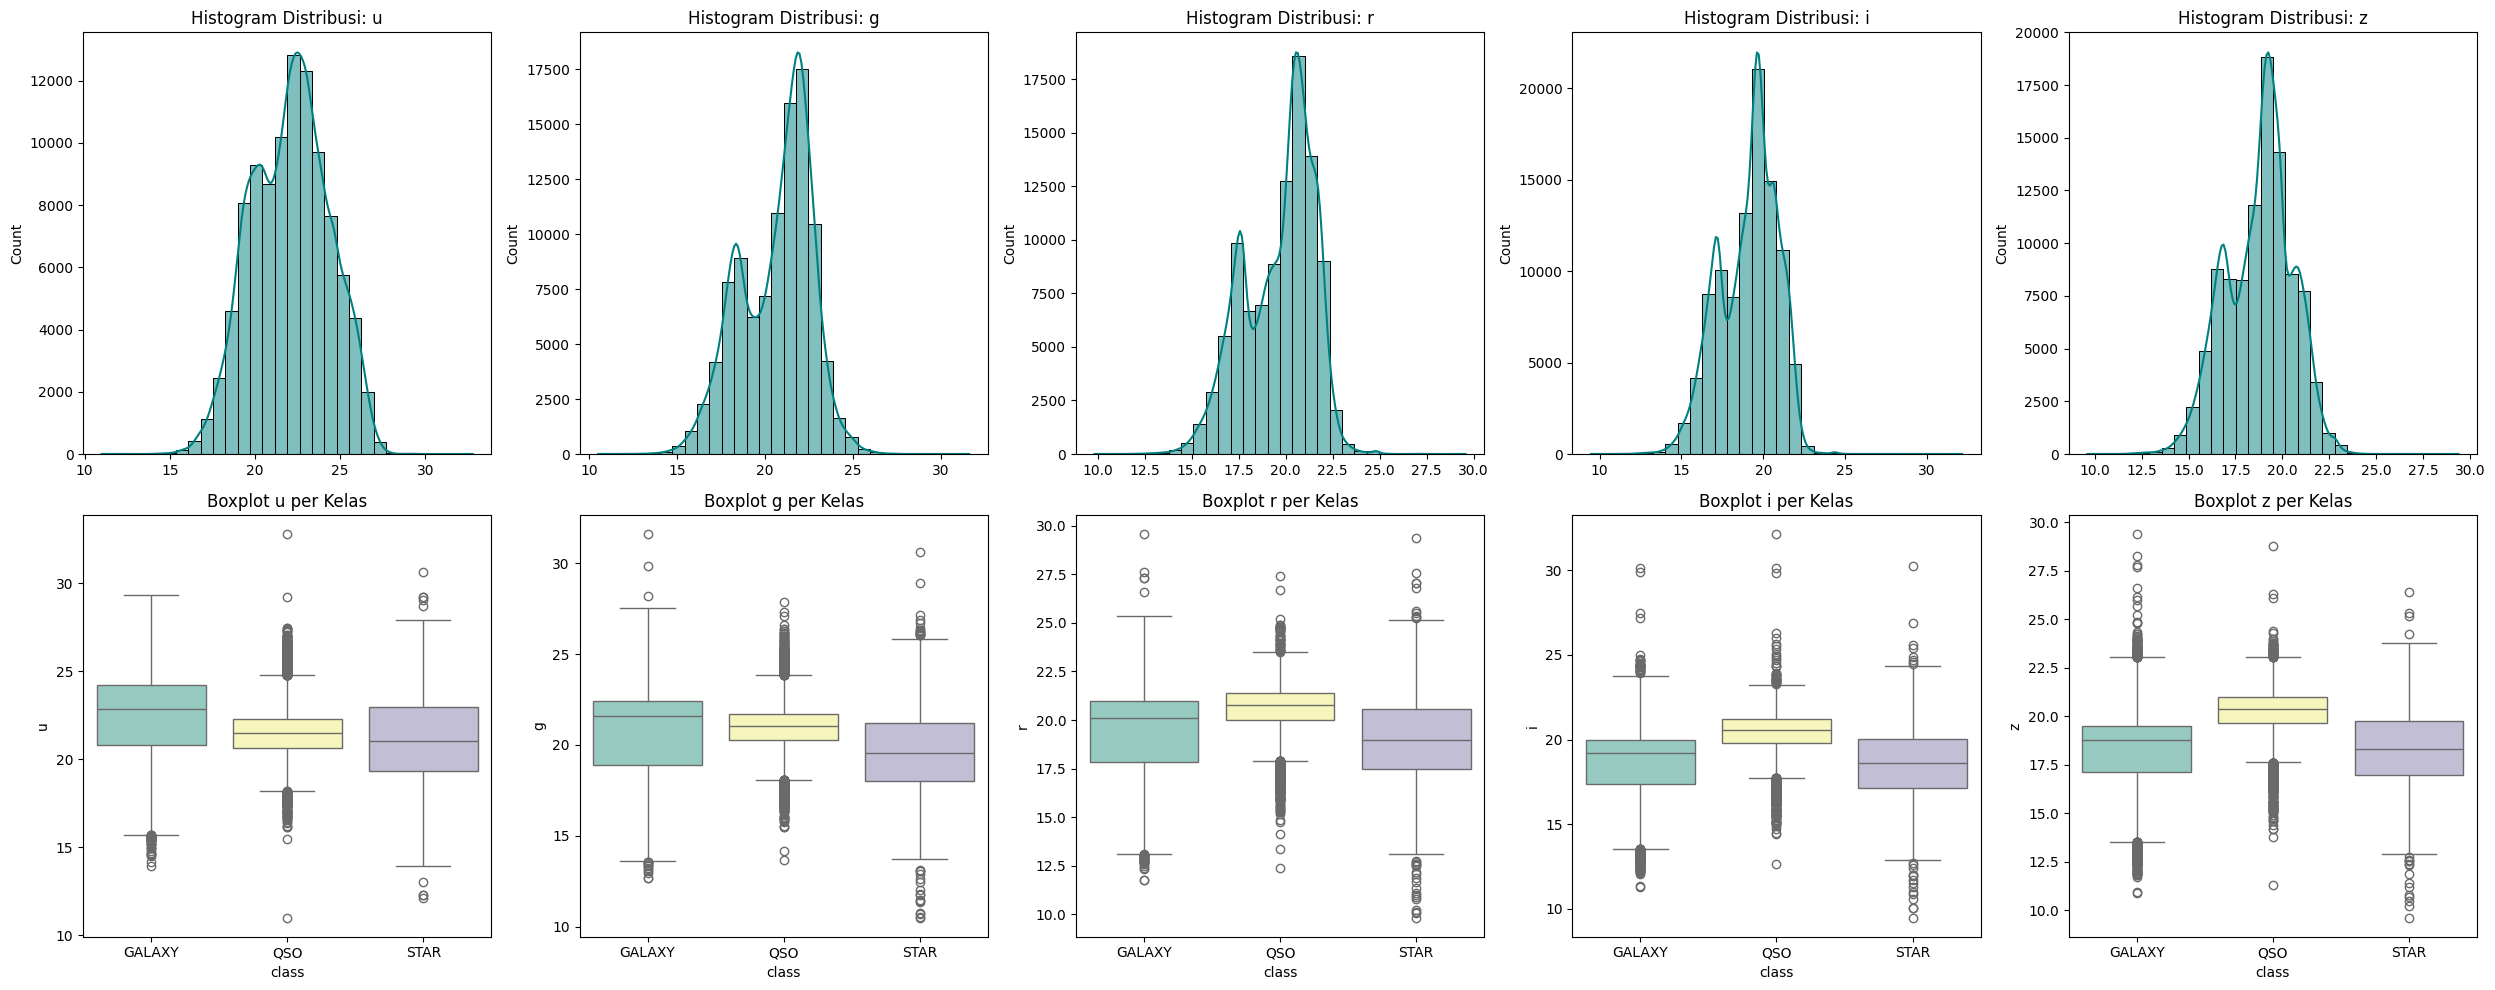

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
mags = ['u', 'g', 'r', 'i', 'z']

for i, col in enumerate(mags):
    # Baris 0: Histogram (Distribusi keseluruhan)
    sns.histplot(data=df, x=col, kde=True, ax=axes[0, i], color='teal', bins=30)
    axes[0, i].set_title(f'Histogram Distribusi: {col}')
    axes[0, i].set_xlabel('')
    
    # Baris 1: Boxplot per Kelas (Mengecek Outlier dan Range per Kelas)
    sns.boxplot(data=df, y=col, x='class', ax=axes[1, i], palette='Set3')
    axes[1, i].set_title(f'Boxplot {col} per Kelas')

plt.tight_layout()
plt.show()

Dari visualisasi di atas, terlihat distribusinya bimodal atau terdapat 2 puncak. Selain itu, ada banyak outlier. Namun dalam konteks astronomi, titik-titik ekstrem tersebut bisa jadi adalah objek dengan luminositas sangat tinggi atau Bintang kerdil yang sangat redup. Adapun boxplot Quasar cenderung sedikit lebih sempit dan lebih padat dibandingkan yang lain, namun sebarannya (whiskers dan outliers) sangat panjang. Ini mencerminkan sifat astrofisika Quasar yang memiliki pancaran energi sangat ekstrem dan bervariasi.


#### 3. Feature Engineering

##### 1) Memberi Flag
Seperti yang telah ditelusuri di tahap EDA sebelumnya, terdapat anomali berupa nilai-nilai membentk garis vertikal. Penanganannya adalah melabeli flag agar model tahu bahwa nilai tersebut dekat dengan ambang teleskop.

In [ ]:
# 1. Flag Nilai Melebihi Ambang Batas
df['u_limit_flag'] = (df['u'] > 24.5).astype(int)
df['r_limit_flag'] = (df['r'] > 24.5).astype(int)

##### 2) Filter Warna Berurutan
Filter SDSS tersusun berurutan berdasarkan panjang gelombang:

u → g → r → i → z

dari:
ultraviolet, visible, near infrared

Masing-masing band menangkap bagian spektrum yang saling berdekatan.
Fitur tambahan diperlukan berupa:
- u-g → slope UV-visible
- g-r → slope visible-red
- r-i → slope red-NIR
- i-z → slope NIR-IR

In [ ]:
# 2. Mengekstrak Warna
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

In [15]:
# Verifikasi hasil perhitungan
print("Statistika Deskriptif Fitur Indeks Warna:")
print(df[['u-g', 'g-r', 'r-i', 'i-z']].describe())

Statistika Deskriptif Fitur Indeks Warna:
                u-g           g-r           r-i           i-z
count  99999.000000  99999.000000  99999.000000  99999.000000
mean       1.449096      0.985806      0.560912      0.315877
std        1.179332      0.734675      0.501518      0.420396
min      -12.748140    -12.318610    -14.649070    -13.162490
25%        0.631245      0.379810      0.216320      0.134500
50%        1.321710      0.931460      0.479800      0.338030
75%        2.044565      1.577985      0.892205      0.474080
max       18.624950     14.315170     12.205800     13.427100


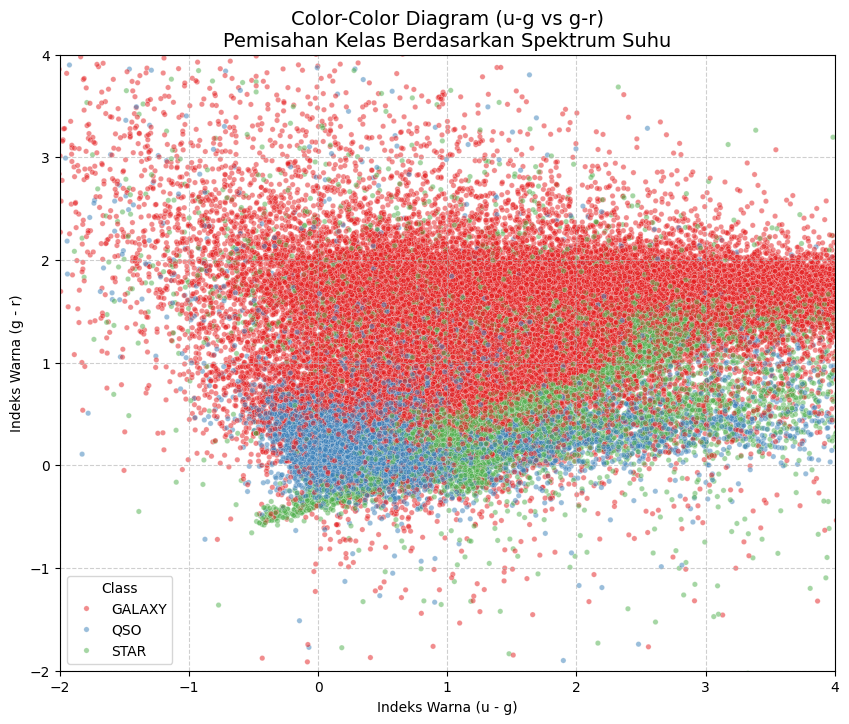

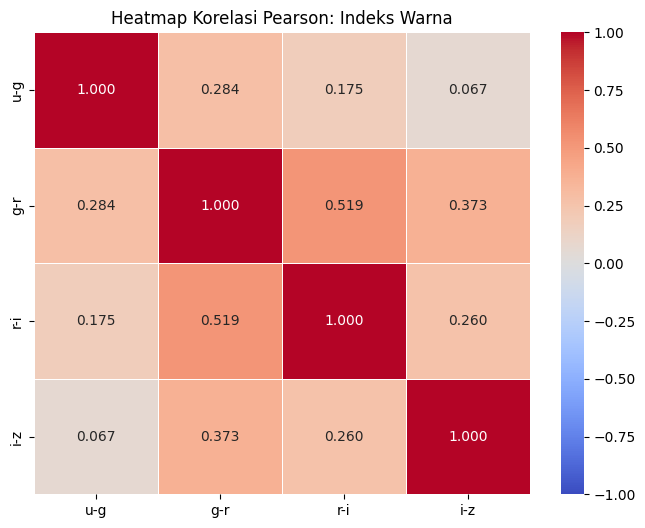

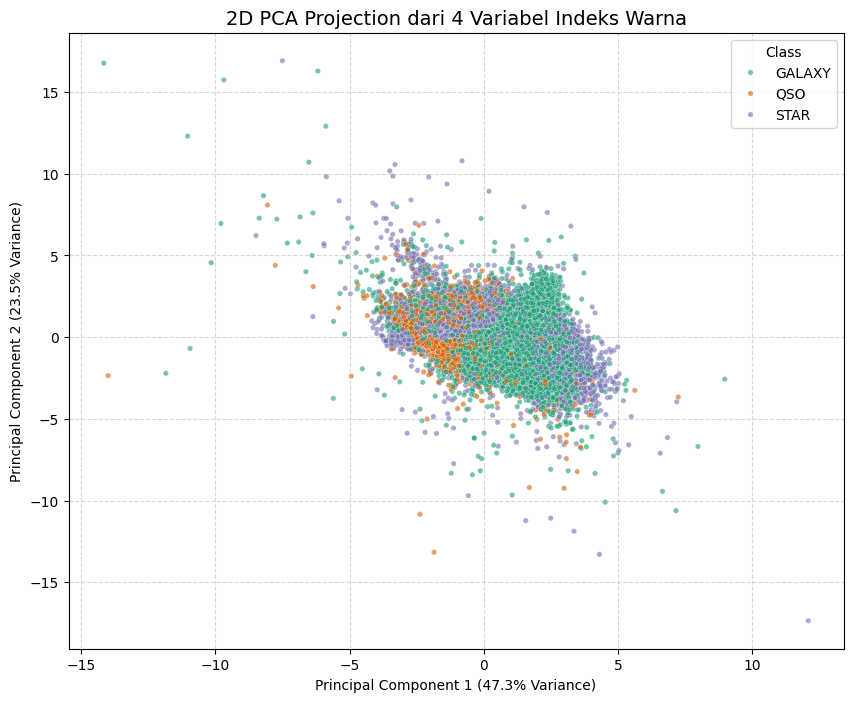

In [ ]:
# VISUALISASI 1: Color-Color Diagram

plt.figure(figsize=(10, 8))
# Memplot u-g vs g-r
sns.scatterplot(data=df, x='u-g', y='g-r', hue='class', 
                palette='Set1', s=15, alpha=0.5)

plt.title('Color-Color Diagram (u-g vs g-r)\nPemisahan Kelas Berdasarkan Spektrum Suhu', fontsize=14)
plt.xlabel('Indeks Warna (u - g)')
plt.ylabel('Indeks Warna (g - r)')

# Memotong sumbu untuk mengabaikan sisa outlier ekstrem agar pola utama terlihat
plt.xlim(-2, 4)
plt.ylim(-2, 4)
plt.legend(title='Class')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# VISUALISASI 2: Heatmap Korelasi (Evaluasi Multikolinearitas)

plt.figure(figsize=(8, 6))
# Matriks korelasi khusus untuk 4 fitur indeks warna baru
corr_matrix_new = df[['u-g', 'g-r', 'r-i', 'i-z']].corr()

sns.heatmap(corr_matrix_new, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt=".3f", linewidths=0.5)

plt.title('Heatmap Korelasi Pearson: Indeks Warna', fontsize=12)
plt.show()

# VISUALISASI 3: Analisis Komponen Utama (PCA)

features_pca = ['u-g', 'g-r', 'r-i', 'i-z']
x = df[features_pca].values

# Standarisasi sebelum PCA agar skala antar variabel seragam
x_scaled = StandardScaler().fit_transform(x)

# Proyeksi ke 2 Komponen Utama
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_scaled)
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['class'] = df['class'].values 

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='class', 
                palette='Dark2', s=15, alpha=0.6)

plt.title('2D PCA Projection dari 4 Variabel Indeks Warna', fontsize=14)
# Menampilkan seberapa besar variansi data asli yang bisa dijelaskan oleh tiap PC
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Class')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Berdasarkan hasil proyeksi PCA 2D yang menunjukkan tumpang tindih kelas secara masif dan batas keputusan yang non-linear, maka pemodelan klasifikasi ini tidak bisa diselesaikan dengan algoritma linear sederhana seperti Regresi Logistik. Oleh karena itu, proyek ini sebaiknya menggunakan algoritma non-linear yang kompleks seperti Random Forest, XGBoost, atau Neural Networks.

##### 3) PCA Components
Indeks warna (u-g, g-r, dll.) masih memiliki korelasi linear terselubung karena mereka berbagi variabel yang sama (misalnya, g ada di u-g dan g-r). PCA akan mengekstrak variansi terbesar dari kombinasi warna ini dan mentransformasikannya menjadi sumbu baru yang ortogonal (sama sekali tidak berkorelasi).

In [ ]:
# 3. Menambah fitur PCA Components 
features_color = ['u-g', 'g-r', 'r-i', 'i-z']
X_color = df[features_color].values

# Standarisasi wajib sebelum PCA
pca_scaler = StandardScaler()
X_color_scaled = pca_scaler.fit_transform(X_color)

# Ekstrak 3 Komponen Utama (Menangkap ~90%+ variansi)
pca = PCA(n_components=3)
pca_features = pca.fit_transform(X_color_scaled)

# Masukkan ke dalam dataframe utama
df['PC1'] = pca_features[:, 0]
df['PC2'] = pca_features[:, 1]
df['PC3'] = pca_features[:, 2]

##### 4) Distance From Stellar Locus

Di alam semesta, bintang-bintang (STAR) memiliki karakteristik radiasi benda hitam yang teratur. Ketika diplot dalam color-color diagram (misalnya u-g vs g-r), bintang tidak tersebar acak, melainkan berkumpul membentuk jalur melengkung yang sangat spesifik dan sempit yang disebut Stellar Locus. Sementara itu, Quasar (QSO) dan Galaksi (GALAXY) tersebar acak jauh di luar jalur tersebut.

In [ ]:
# 4. Menambah Fitur Distance From Stellar Locus
# Pisahkan data yang khusus bertipe 'STAR' untuk mendesain garis Locus
df_stars = df[df['class'] == 'STAR']

# petakan Locus pada diagram paling populer: u-g (Sumbu X) vs g-r (Sumbu Y)
X_star_ug = df_stars['u-g']
y_star_gr = df_stars['g-r']

# Buat model garis Locus menggunakan Regresi Polinomial Derajat 3
poly_coeffs = np.polyfit(X_star_ug, y_star_gr, deg=3)
locus_function = np.poly1d(poly_coeffs)

# Hitung jarak absolut (residual) dari fungsi Locus untuk SEMUA data
# Jarak = | y_aktual - y_prediksi_locus |
df['dist_locus'] = np.abs(df['g-r'] - locus_function(df['u-g']))

In [ ]:
# Melihat Pusat dan Sebaran Fitur Baru

print("=== Verifikasi Fitur Hasil Engineering ===")
print(df[['PC1', 'PC2', 'PC3', 'dist_locus']].head())

print("\n=== Rata-rata Jarak ke Stellar Locus per Kelas ===")
print(df.groupby('class')['dist_locus'].mean())

=== Verifikasi Fitur Hasil Engineering ===
        PC1       PC2       PC3  dist_locus
0  1.593419 -0.075713 -0.851803    1.235004
1 -0.337458  1.195043 -1.993974    0.484991
2  2.090204  0.593385 -0.565674    1.132083
3  1.700169 -3.495430 -0.344248    1.283115
4  0.276968  0.149234  0.348347    0.374018

=== Rata-rata Jarak ke Stellar Locus per Kelas ===
class
GALAXY    0.656184
QSO       0.356043
STAR      0.369523
Name: dist_locus, dtype: float64


#### 4. Modelling & Evaluation

##### Persiapan

Dalam modelling ini hanya akan digunakan variabel x berupa:                                                             
'r', 'u-g', 'g-r', 'r-i', 'i-z', 'PC1', 'PC2', 'PC3', 'dist_locus', 'u_limit_flag',                         'r_limit_flag'                                                                                                                                   
Sedangkan untuk 'u', 'g', 'i', 'z' tidak digunakan karena ia akan memicu multikolinearitas berbahaya.

In [20]:
# 1. Definisikan Matriks Fitur (X) dan Target (y)
fitur_final = ['r', 'u-g', 'g-r', 'r-i', 'i-z', 'PC1', 'PC2', 'PC3', 'dist_locus', 'u_limit_flag', 'r_limit_flag']
X = df[fitur_final]
y_raw = df['class']

# 2. Label Encoding WAJIB untuk XGBoost
# Mengubah 'GALAXY', 'QSO', 'STAR' menjadi angka 0, 1, 2
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)
kelas_target = encoder.classes_
print(f"Mapping Kelas Target: {dict(enumerate(kelas_target))}\n")

# 3. Train-Test Split (80% Pelatihan, 20% Pengujian)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Standarisasi Fitur (Sangat penting untuk Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Mapping Kelas Target: {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}



Permodelan dengan 3 Model : Logistic Regression (baseline), XGBoost, Random Forest

In [ ]:
# Inisialisasi Model

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        random_state=42,
        eval_metric='mlogloss',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1
    )
}

# Training dan koleksi metrik evaluasi

from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

results = {}

for nama_model, model in models.items():
    print(f"Melatih: {nama_model}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[nama_model] = {
        'model'           : model,
        'y_pred'          : y_pred,
        'accuracy'        : accuracy_score(y_test, y_pred),
        'f1_macro'        : f1_score(y_test, y_pred, average='macro'),
        'f1_weighted'     : f1_score(y_test, y_pred, average='weighted'),
        'f1_per_kelas'    : f1_score(y_test, y_pred, average=None),
        'recall_macro'    : recall_score(y_test, y_pred, average='macro'),
        'recall_weighted' : recall_score(y_test, y_pred, average='weighted'),
        'recall_per_kelas': recall_score(y_test, y_pred, average=None),
    }

print("✅ Semua model selesai dilatih.\n")

Melatih: Logistic Regression...
Melatih: Random Forest...
Melatih: XGBoost...
✅ Semua model selesai dilatih.



Hasil Evaluasi

RINGKASAN PERFORMA MODEL
Model                    Accuracy   F1 Macro   F1 Weighted   Recall Macro   Recall Weighted
----------------------------------------------------------------------
Logistic Regression        0.7587     0.6706        0.7362         0.6724            0.7587
Random Forest              0.8841     0.8511        0.8825         0.8414            0.8841
XGBoost                    0.8866     0.8541        0.8853         0.8458            0.8866

📌 Logistic Regression
              precision    recall  f1-score   support

      GALAXY       0.80      0.91      0.85     11889
         QSO       0.68      0.79      0.74      3792
        STAR       0.67      0.31      0.43      4319

    accuracy                           0.76     20000
   macro avg       0.72      0.67      0.67     20000
weighted avg       0.75      0.76      0.74     20000


📌 Random Forest
              precision    recall  f1-score   support

      GALAXY       0.91      0.95      0.93     11889
      

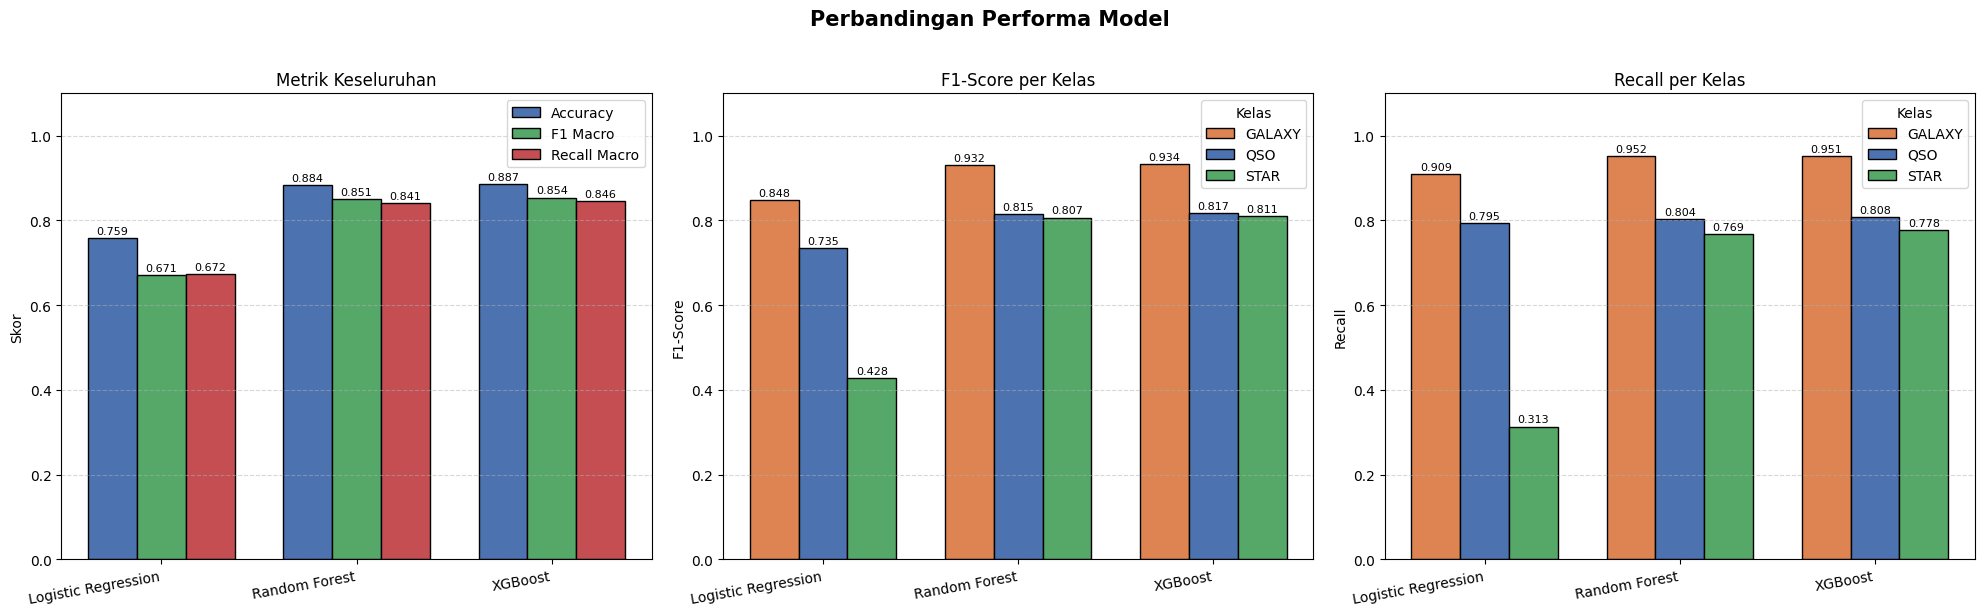

In [ ]:
# Tabel Ringkasan Keseluruhan

print("=" * 70)
print("RINGKASAN PERFORMA MODEL")
print("=" * 70)
print(f"{'Model':<22} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>13} {'Recall Macro':>14} {'Recall Weighted':>17}")
print("-" * 70)
for nama, r in results.items():
    print(f"{nama:<22} {r['accuracy']:>10.4f} {r['f1_macro']:>10.4f} {r['f1_weighted']:>13.4f} {r['recall_macro']:>14.4f} {r['recall_weighted']:>17.4f}")
print("=" * 70)

# Classification Report

for nama, r in results.items():
    print(f"\n{'='*60}")
    print(f"📌 {nama}")
    print(f"{'='*60}")
    print(classification_report(y_test, r['y_pred'], target_names=kelas_target))

# Visualisasi Hasil Evaluasi

nama_model_list = list(results.keys())
x = np.arange(len(nama_model_list))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Perbandingan Performa Model', fontsize=15, fontweight='bold', y=1.02)

# --- Panel 1: Accuracy, F1 Macro, Recall Macro (Overall) ---
ax = axes[0]
metrics_overall = {
    'Accuracy'    : [results[n]['accuracy']     for n in nama_model_list],
    'F1 Macro'    : [results[n]['f1_macro']      for n in nama_model_list],
    'Recall Macro': [results[n]['recall_macro']  for n in nama_model_list],
}
colors_overall = ['#4C72B0', '#55A868', '#C44E52']
for idx, (label, vals) in enumerate(metrics_overall.items()):
    bars = ax.bar(x + idx * width, vals, width, label=label, color=colors_overall[idx], edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(nama_model_list, rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Metrik Keseluruhan')
ax.set_ylabel('Skor')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: F1-Score per Kelas ---
ax = axes[1]
colors_kelas = ['#DD8452', '#4C72B0', '#55A868']
for idx, kelas in enumerate(kelas_target):
    vals = [results[n]['f1_per_kelas'][idx] for n in nama_model_list]
    bars = ax.bar(x + idx * width, vals, width, label=kelas, color=colors_kelas[idx], edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(nama_model_list, rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('F1-Score per Kelas')
ax.set_ylabel('F1-Score')
ax.legend(title='Kelas')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 3: Recall per Kelas ---
ax = axes[2]
for idx, kelas in enumerate(kelas_target):
    vals = [results[n]['recall_per_kelas'][idx] for n in nama_model_list]
    bars = ax.bar(x + idx * width, vals, width, label=kelas, color=colors_kelas[idx], edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(nama_model_list, rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Recall per Kelas')
ax.set_ylabel('Recall')
ax.legend(title='Kelas')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Melihat Feature Importance

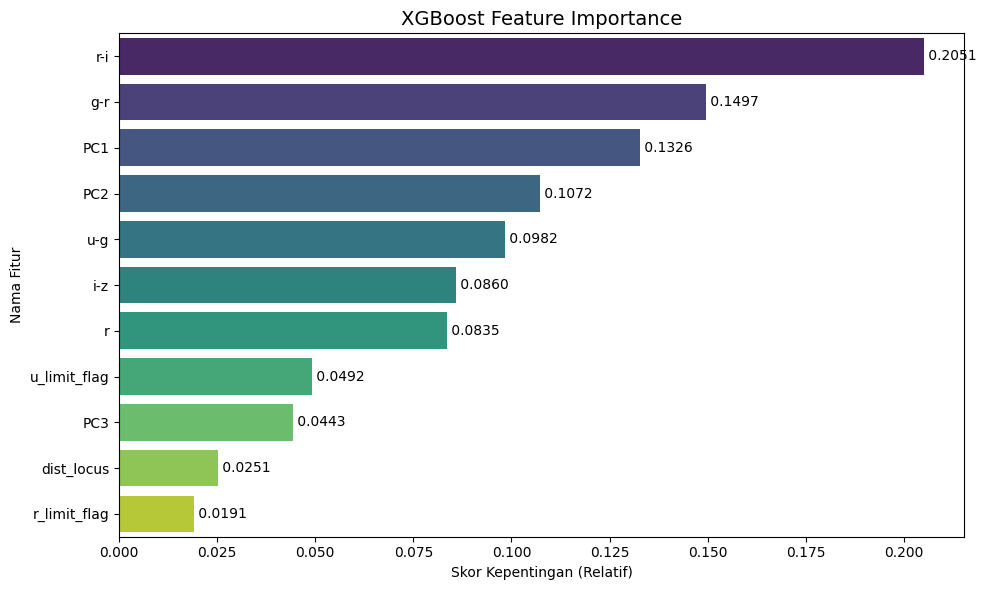

In [ ]:
# Ekstrak model XGBoost 
xgb_model = models["XGBoost"]

# Ambil nilai feature importances bawaan model
importances = xgb_model.feature_importances_

# Buat DataFrame 
df_importance = pd.DataFrame({
    'Fitur': fitur_final,
    'Tingkat Kepentingan (Gain)': importances
})
df_importance = df_importance.sort_values(by='Tingkat Kepentingan (Gain)', ascending=False)

# 4. Visualisasi dengan Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Kepentingan (Gain)', y='Fitur', data=df_importance, palette='viridis')

plt.title('XGBoost Feature Importance', fontsize=14)
plt.xlabel('Skor Kepentingan (Relatif)')
plt.ylabel('Nama Fitur')

for index, value in enumerate(df_importance['Tingkat Kepentingan (Gain)']):
    plt.text(value, index, f' {value:.4f}', va='center')

plt.tight_layout()
plt.show()

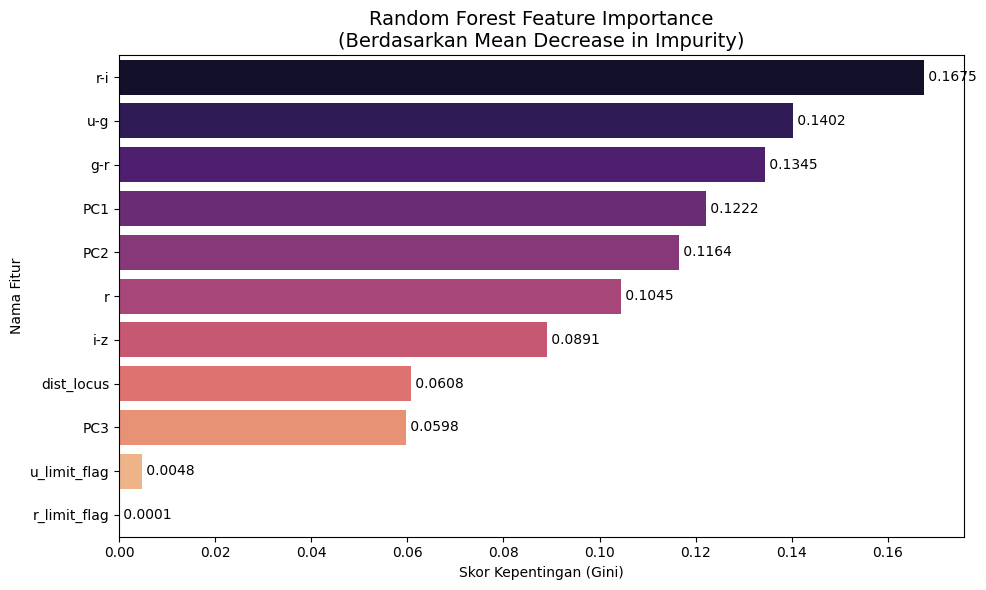

In [32]:
# Ekstrak model Random Forest 
rf_model = models["Random Forest"]

# 2. Ambil nilai feature importances bawaan model RF (berbasis Gini Impurity)
rf_importances = rf_model.feature_importances_

# 3. Buat DataFrame dan urutkan
df_rf_importance = pd.DataFrame({
    'Fitur': fitur_final, 
    'Tingkat Kepentingan (Gini)': rf_importances
})
df_rf_importance = df_rf_importance.sort_values(by='Tingkat Kepentingan (Gini)', ascending=False)

# 4. Visualisasi dengan Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Kepentingan (Gini)', y='Fitur', data=df_rf_importance, palette='magma')

plt.title('Random Forest Feature Importance\n(Berdasarkan Mean Decrease in Impurity)', fontsize=14)
plt.xlabel('Skor Kepentingan (Gini)')
plt.ylabel('Nama Fitur')

for index, value in enumerate(df_rf_importance['Tingkat Kepentingan (Gini)']):
    plt.text(value, index, f' {value:.4f}', va='center')

plt.tight_layout()
plt.show()

Menyimpan Model

In [ ]:
# Simpan Model 
joblib.dump(xgb_model, "model/xgb_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(encoder, "model/label_encoder.pkl")
joblib.dump(pca_scaler, "model/pca_scaler.pkl")
joblib.dump(pca, "model/pca.pkl")
joblib.dump(poly_coeffs, "model/locus_coeffs.pkl")

print("Artefak model dan preprocessor berhasil diekspor!")

Artefak model dan preprocessor berhasil diekspor!
